##Building a multiclass classifier


# Creating multiclass classification data

To do so, we can leverage Scikit-Learn's make_blobs() method.

This method will create however many classes (using the centers parameter) we want.



tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


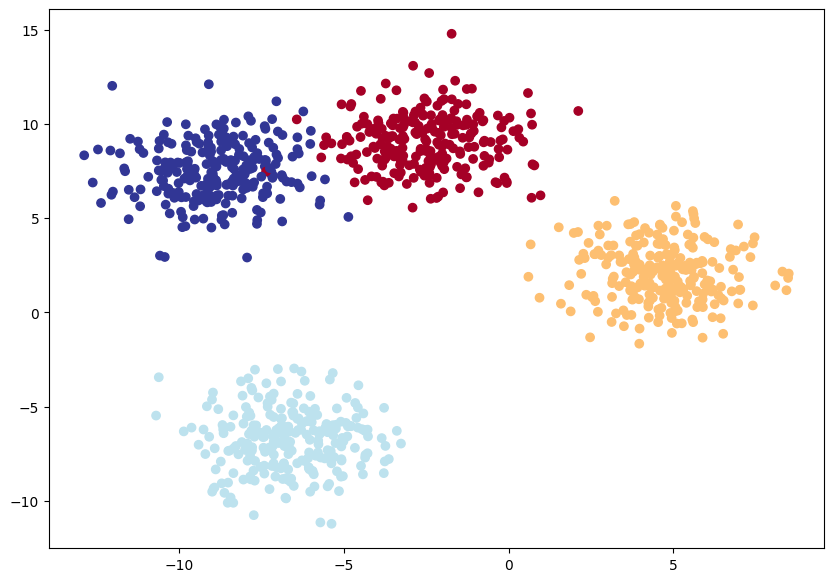

In [1]:
# Importing dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1 Create multi-class clssification
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES, # X features
                            centers=NUM_CLASSES, # y labels
                            cluster_std=1.5, # give clusters  a little shake up
                            random_state=RANDOM_SEED
                            )

# 2 Trun data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3 Split the data into train and test sets
X_blob_train,X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                       y_blob,
                                                                       test_size=0.2,
                                                                       random_state=RANDOM_SEED
                                                                       )

# 4 Plot the data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)


# Building a multiclass Classification in PyTorch


In [2]:
# Creating a device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
from torch import nn

# Build model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features,hidden_units=8):
    """ Initalize all required hyperparameters for a multiclass classification model.
        Args:
        Input_features (int): Number of input  features to the model
        out_features (int) : Number of output features to the model
        (how many classes are there)
        hidden_units (int): Number of hiddend units between layers , default to 8
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)

    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

Excellent! Our multiclass classification model is ready to go, now we create a loss function and optimize for it

#Creating a loss function and optimizer for a multiclass PyTorch model

Since we're working on a multi-class classification problem, we'll use the nn.CrossEntropyLoss() method as our loss function.

In [5]:
# Creating loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(),
                            lr=0.1)

#Getting prediction probabilites for a multiclas PyToch model

In [6]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]



tensor([[-0.2192, -0.1155, -0.4375,  0.1978],
        [-0.9490,  0.9706,  1.4515,  1.1988],
        [ 1.8927,  0.6908, -0.5625,  0.4608],
        [ 1.1644,  0.6536, -0.1937,  0.5628],
        [-0.5961,  0.9339,  1.1988,  1.1055]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [8]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [9]:
# Make predictions for logits with model
y_logits = model_4(X_blob_test.to(device))

# Preform softmax  calcultaion on logits across dimension 1 to get the prediction probabilites
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.3826, -0.0207, -0.2153,  0.3032],
        [-0.4397,  1.3972,  1.7354,  1.4479],
        [ 1.6686,  0.5164, -0.6695,  0.3617],
        [ 0.1226, -0.0776, -0.5830,  0.1663],
        [-1.0994,  0.7454,  1.2335,  1.0458]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1785, 0.2563, 0.2110, 0.3543],
        [0.0441, 0.2767, 0.3881, 0.2911],
        [0.5941, 0.1877, 0.0573, 0.1608],
        [0.2979, 0.2438, 0.1471, 0.3112],
        [0.0382, 0.2417, 0.3938, 0.3264]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [10]:
# Sum the first sample output of the softmax activation function
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

These prediction probabilities are essentially saying how much the model thinks the target X sample (the input) maps to each class.

In [12]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])

print(torch.argmax(y_pred_probs[0]))

tensor([0.1785, 0.2563, 0.2110, 0.3543], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='cuda:0')


Note: To summarize the above, a model's raw output is referred to as logits.

For a multi-class classification problem, to turn the logits into prediction probabilities, you use the softmax activation function (torch.softmax).

The index of the value with the highest prediction probability is the class number the model thinks is most likely given the input features for that sample (although this is a prediction, it doesn't mean it will be correct).

#Creating a training and testing loop for a multi-class PyTorch model

In [16]:
def accuracy_fn(y_true, y_pred):
  """ Calculat the accuaracy in percentage"""
  correct = (y_true == y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [17]:
# Fit the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    # Training
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train)  # Model outputs raw logits
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)  # logits -> probs -> predicted labels

    # 2. Calculate the loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)  # CrossEntropyLoss expects raw logits
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_preds)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # --- Testing ---
    model_4.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d} | "
              f"Loss: {loss:.5f}, Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 000 | Loss: 2.13327, Acc: 0.12% | Test Loss: 1.03203, Test Acc: 50.50%
Epoch: 010 | Loss: 0.21480, Acc: 95.62% | Test Loss: 0.17981, Test Acc: 97.50%
Epoch: 020 | Loss: 0.08857, Acc: 99.00% | Test Loss: 0.07949, Test Acc: 99.50%
Epoch: 030 | Loss: 0.06299, Acc: 98.88% | Test Loss: 0.05504, Test Acc: 99.50%
Epoch: 040 | Loss: 0.05143, Acc: 98.88% | Test Loss: 0.04356, Test Acc: 99.50%
Epoch: 050 | Loss: 0.04495, Acc: 98.88% | Test Loss: 0.03694, Test Acc: 99.50%
Epoch: 060 | Loss: 0.04085, Acc: 99.00% | Test Loss: 0.03267, Test Acc: 99.50%
Epoch: 070 | Loss: 0.03805, Acc: 99.00% | Test Loss: 0.02968, Test Acc: 99.50%
Epoch: 080 | Loss: 0.03602, Acc: 99.12% | Test Loss: 0.02748, Test Acc: 99.50%
Epoch: 090 | Loss: 0.03450, Acc: 99.12% | Test Loss: 0.02579, Test Acc: 99.50%


# Making and evaluating predications with a pytorch multiclass model

In [18]:
# Make predictions
model_4.eval()

with torch.inference_mode():
  y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]


tensor([[  5.8561,  11.7339, -13.5186,  -7.6285],
        [  4.9244, -11.8058,   3.2405,  10.7313],
        [ -8.7784, -16.0612,  19.7441,  11.3443],
        [  2.4283,   8.0977,  -7.6606,  -5.4490],
        [ 10.0785,   5.2615, -13.3691,  -1.6849],
        [  5.4214, -14.7398,   4.7190,  13.1423],
        [ -9.0192, -12.8244,  17.8070,   8.7460],
        [  8.4741,   0.6999,  -8.7041,   1.5882],
        [ -9.2049, -21.6288,  23.9132,  15.6456],
        [  8.8992,   2.3324, -10.2252,   0.3871]], device='cuda:0')

In [19]:
# Turn predicted logits in predictions probabilties
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn the prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare the first 10 model preds and test labels
print(f" Predictions :  {y_preds[:10]}\nLables: {y_blob_test[:10]}")
print(f"Test Accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

 Predictions :  tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Lables: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test Accuracy: 99.5%


In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    # Make sure model is in evaluation mode
    model.eval()

    # Move tensors to CPU for plotting
    X, y = X.to("cpu"), y.to("cpu")

    # Define the range for the grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Create a grid of points
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Predict over the grid
    with torch.inference_mode():
        grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

        # If your model is on GPU, move grid to same device
        device = next(model.parameters()).device
        grid = grid.to(device)

        preds = model(grid)

        # Handle binary or multiclass
        if preds.shape[1] == 1:  # Binary classification
            preds = torch.sigmoid(preds)
            preds = torch.round(preds)
        else:  # Multiclass classification
            preds = torch.softmax(preds, dim=1).argmax(dim=1)

        # Move predictions back to CPU for plotting
        preds = preds.reshape(xx.shape).cpu()

    # Plot the decision boundary
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


Here our model predictions are the same form as test labels

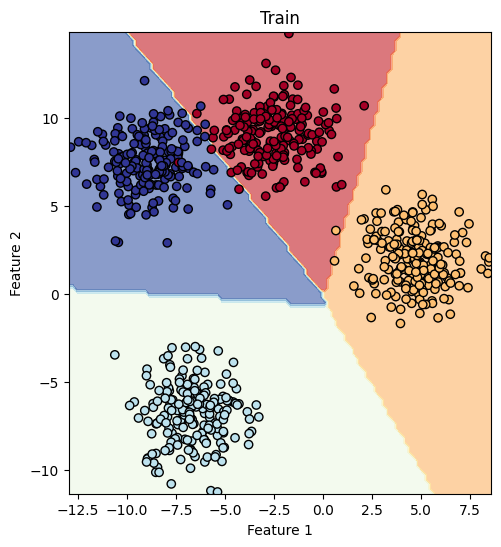

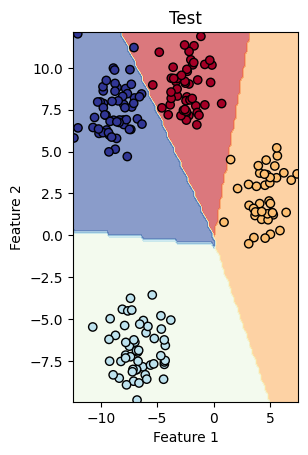

In [26]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)